# Master in Applied Artificial Intelligence

## Course: *Computer Vision for Images and Video*

### **5.4 Google Colab** - Image enhancement algorithms in the Fourier domain

---

**Institution:** Tecnológico de Monterrey

**Instructors:** Gilberto Ochoa Ruiz, Daniel Flores Araiza, Ma. del Refugio Meléndez Alfaro

**Authors (Team 38):** 

|  FULL NAME                      |     STUDENT ID    | 
| :--------------------------:    |:-----------------:|
| Alejandro Díaz Villagómez       |  A01276769        | 
| Carlos Rodrigo Sánchez Sierra   |  A01424454        | 
| Emiliano Saucedo Arriola        |  A01659258        | 

**Date:** October 12th, 2025

---

# 5. Frequency Domain

## Table of Contents
1. [Libraries](#libraries)
2. [Fast Fourier Transform (FFT)](#fft)
3. [Low Pass Filter](#low)
4. [High Pass Filter](#high)

## Importing Libraries <a class="anchor" id="libraries" ></a>

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from math import sqrt,exp

## Fast Fourier Transform (FFT) <a class="anchor" id="fft" ></a>

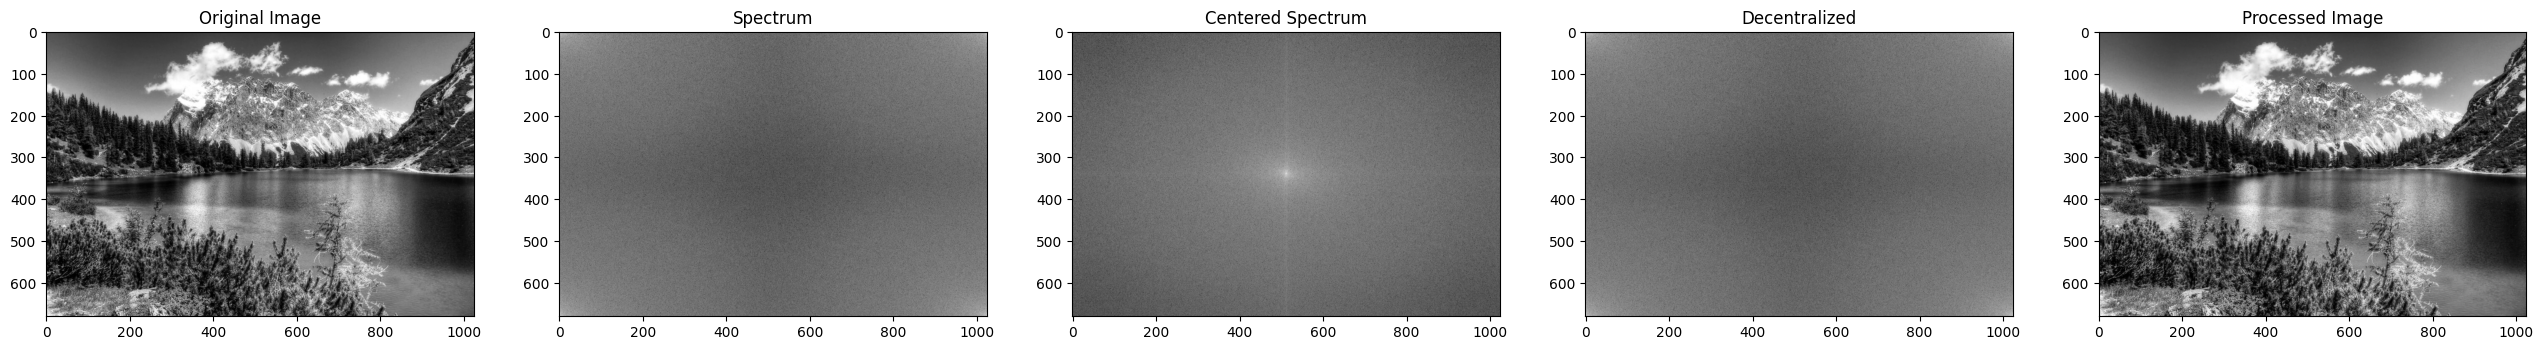

In [2]:
plt.figure(figsize=(6.4*5, 4.8*5), constrained_layout=False)

img = cv2.imread("data/image.jpg", 0)
plt.subplot(151), plt.imshow(img, "gray"), plt.title("Original Image")

original = np.fft.fft2(img)
plt.subplot(152), plt.imshow(np.log(1+np.abs(original)), "gray"), plt.title("Spectrum")

center = np.fft.fftshift(original)
plt.subplot(153), plt.imshow(np.log(1+np.abs(center)), "gray"), plt.title("Centered Spectrum")

inv_center = np.fft.ifftshift(center)
plt.subplot(154), plt.imshow(np.log(1+np.abs(inv_center)), "gray"), plt.title("Decentralized")

processed_img = np.fft.ifft2(inv_center)
plt.subplot(155), plt.imshow(np.abs(processed_img), "gray"), plt.title("Processed Image")

plt.show()

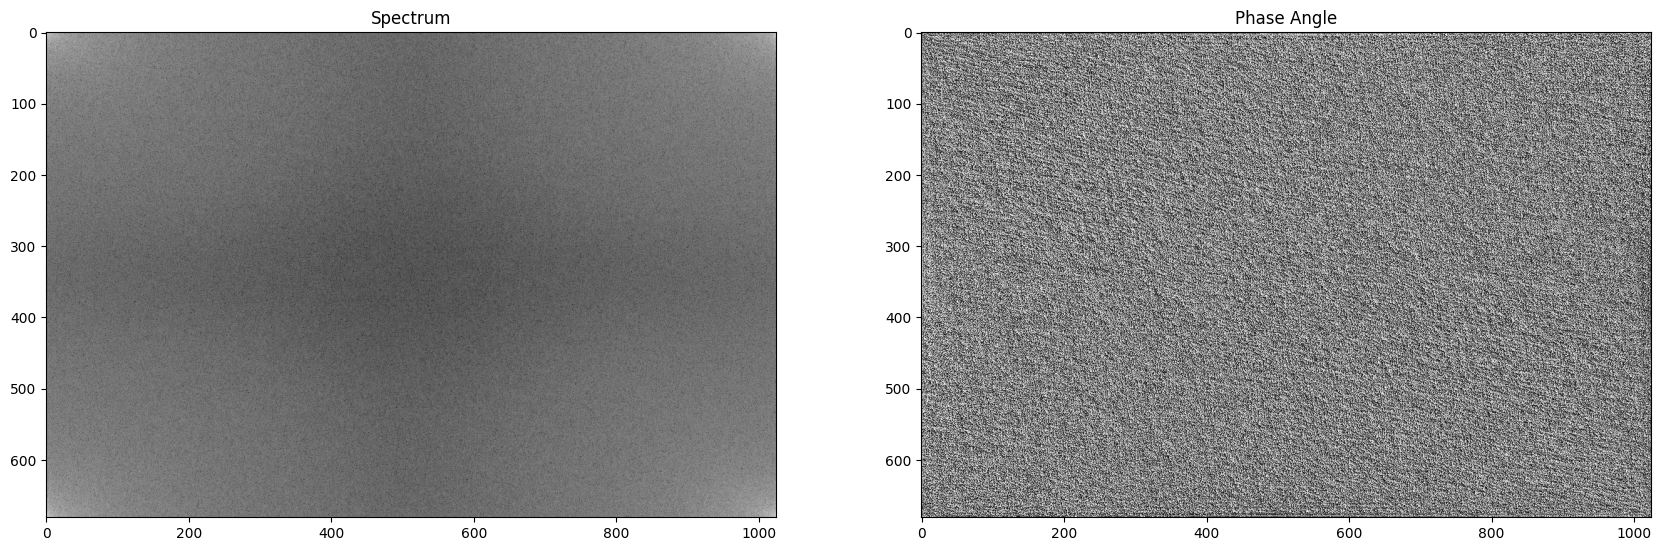

In [3]:
plt.figure(figsize=(6.4*5, 4.8*5), constrained_layout=False)

img = cv2.imread("data/image.jpg", 0)

original = np.fft.fft2(img)
plt.subplot(131), plt.imshow(np.log(np.abs(original)), "gray"), plt.title("Spectrum")

plt.subplot(132), plt.imshow(np.angle(original), "gray"), plt.title("Phase Angle")
plt.show()

In [4]:
def distance(point1,point2):
    return sqrt((point1[0]-point2[0])**2 + (point1[1]-point2[1])**2)

def idealFilterLP(D0,imgShape):
    base = np.zeros(imgShape[:2])
    rows, cols = imgShape[:2]
    center = (rows/2,cols/2)
    for x in range(cols):
        for y in range(rows):
            if distance((y,x),center) < D0:
                base[y,x] = 1
    return base

def idealFilterHP(D0,imgShape):
    base = np.ones(imgShape[:2])
    rows, cols = imgShape[:2]
    center = (rows/2,cols/2)
    for x in range(cols):
        for y in range(rows):
            if distance((y,x),center) < D0:
                base[y,x] = 0
    return base

def butterworthLP(D0,imgShape,n):
    base = np.zeros(imgShape[:2])
    rows, cols = imgShape[:2]
    center = (rows/2,cols/2)
    for x in range(cols):
        for y in range(rows):
            base[y,x] = 1/(1+(distance((y,x),center)/D0)**(2*n))
    return base

def butterworthHP(D0,imgShape,n):
    base = np.zeros(imgShape[:2])
    rows, cols = imgShape[:2]
    center = (rows/2,cols/2)
    for x in range(cols):
        for y in range(rows):
            base[y,x] = 1-1/(1+(distance((y,x),center)/D0)**(2*n))
    return base

def gaussianLP(D0,imgShape):
    base = np.zeros(imgShape[:2])
    rows, cols = imgShape[:2]
    center = (rows/2,cols/2)
    for x in range(cols):
        for y in range(rows):
            base[y,x] = exp(((-distance((y,x),center)**2)/(2*(D0**2))))
    return base

def gaussianHP(D0,imgShape):
    base = np.zeros(imgShape[:2])
    rows, cols = imgShape[:2]
    center = (rows/2,cols/2)
    for x in range(cols):
        for y in range(rows):
            base[y,x] = 1 - exp(((-distance((y,x),center)**2)/(2*(D0**2))))
    return base

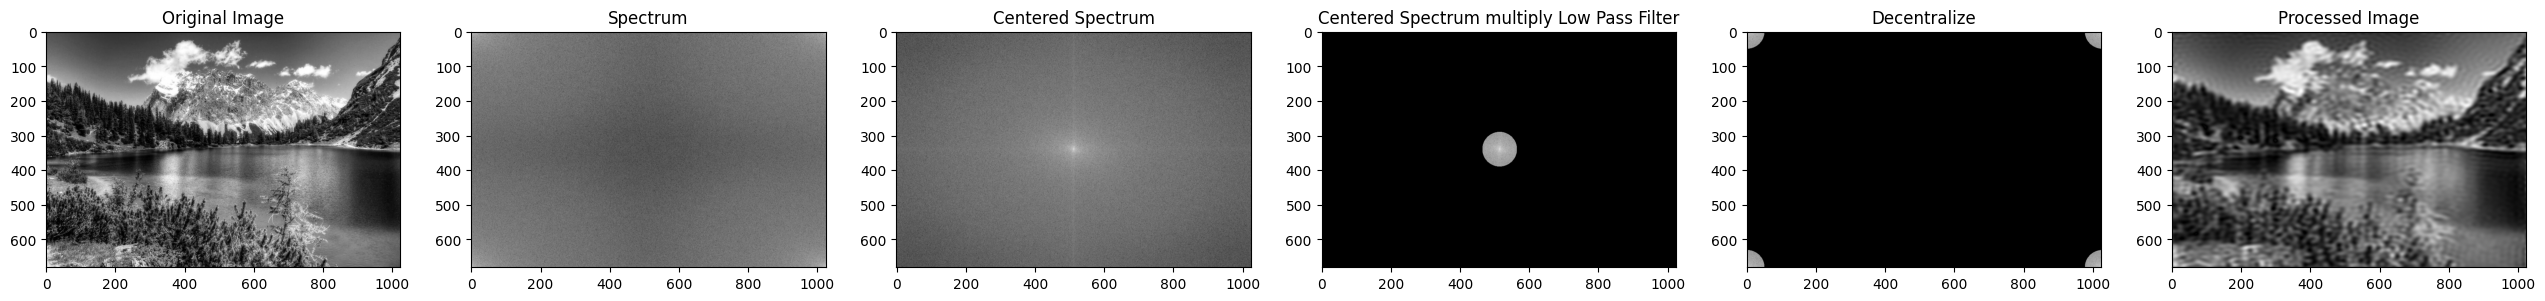

In [5]:
plt.figure(figsize=(6.4*5, 4.8*5), constrained_layout=False)

img = cv2.imread("data/image.jpg", 0)
plt.subplot(161), plt.imshow(img, "gray"), plt.title("Original Image")

original = np.fft.fft2(img)
plt.subplot(162), plt.imshow(np.log(1+np.abs(original)), "gray"), plt.title("Spectrum")

center = np.fft.fftshift(original)
plt.subplot(163), plt.imshow(np.log(1+np.abs(center)), "gray"), plt.title("Centered Spectrum")

LowPassCenter = center * idealFilterLP(50,img.shape)
plt.subplot(164), plt.imshow(np.log(1+np.abs(LowPassCenter)), "gray"), plt.title("Centered Spectrum multiply Low Pass Filter")

LowPass = np.fft.ifftshift(LowPassCenter)
plt.subplot(165), plt.imshow(np.log(1+np.abs(LowPass)), "gray"), plt.title("Decentralize")

inverse_LowPass = np.fft.ifft2(LowPass)
plt.subplot(166), plt.imshow(np.abs(inverse_LowPass), "gray"), plt.title("Processed Image")

plt.show()

## Low Pass Filter <a class="anchor" id="low" ></a>

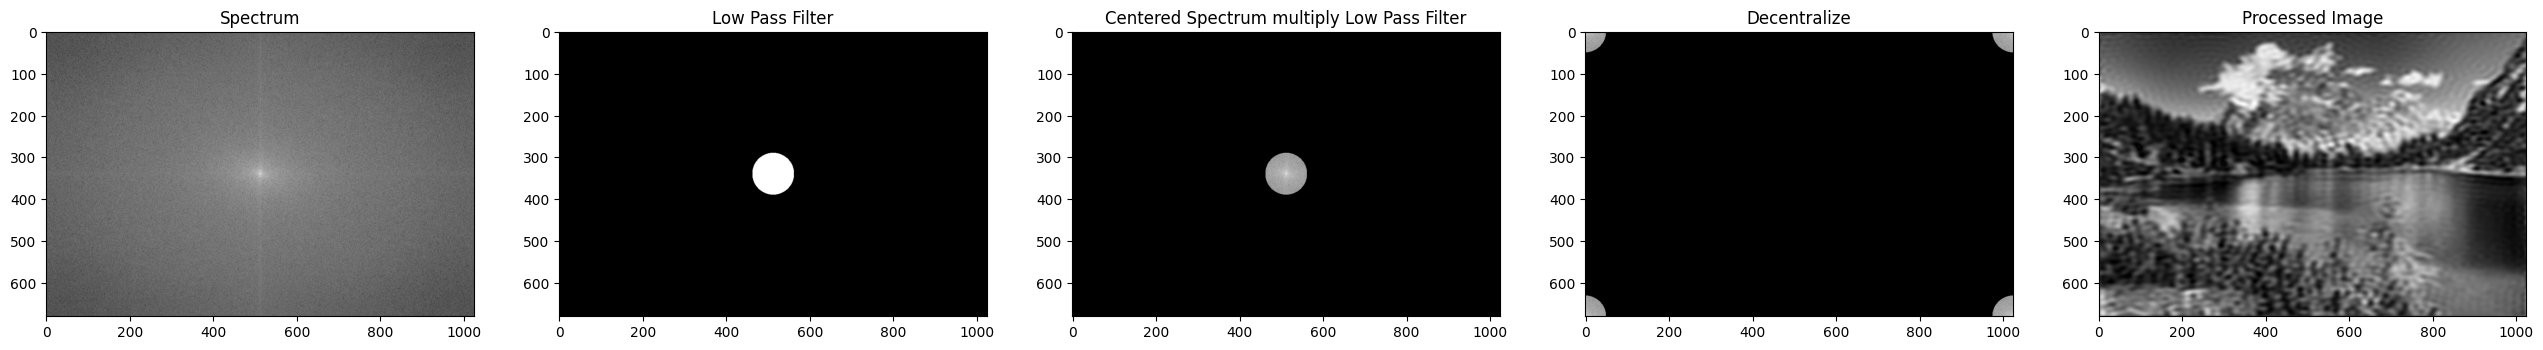

In [6]:
img = cv2.imread("data/image.jpg", 0)
original = np.fft.fft2(img)
center = np.fft.fftshift(original)

plt.figure(figsize=(6.4*5, 4.8*5), constrained_layout=False)

plt.subplot(151), plt.imshow(np.log(1+np.abs(center)), "gray"), plt.title("Spectrum")

LowPass = idealFilterLP(50,img.shape)
plt.subplot(152), plt.imshow(np.abs(LowPass), "gray"), plt.title("Low Pass Filter")

LowPassCenter = center * idealFilterLP(50,img.shape)
plt.subplot(153), plt.imshow(np.log(1+np.abs(LowPassCenter)), "gray"), plt.title("Centered Spectrum multiply Low Pass Filter")

LowPass = np.fft.ifftshift(LowPassCenter)
plt.subplot(154), plt.imshow(np.log(1+np.abs(LowPass)), "gray"), plt.title("Decentralize")

inverse_LowPass = np.fft.ifft2(LowPass)
plt.subplot(155), plt.imshow(np.abs(inverse_LowPass), "gray"), plt.title("Processed Image")

plt.show()

## High Pass Filter <a class="anchor" id="high" ></a>

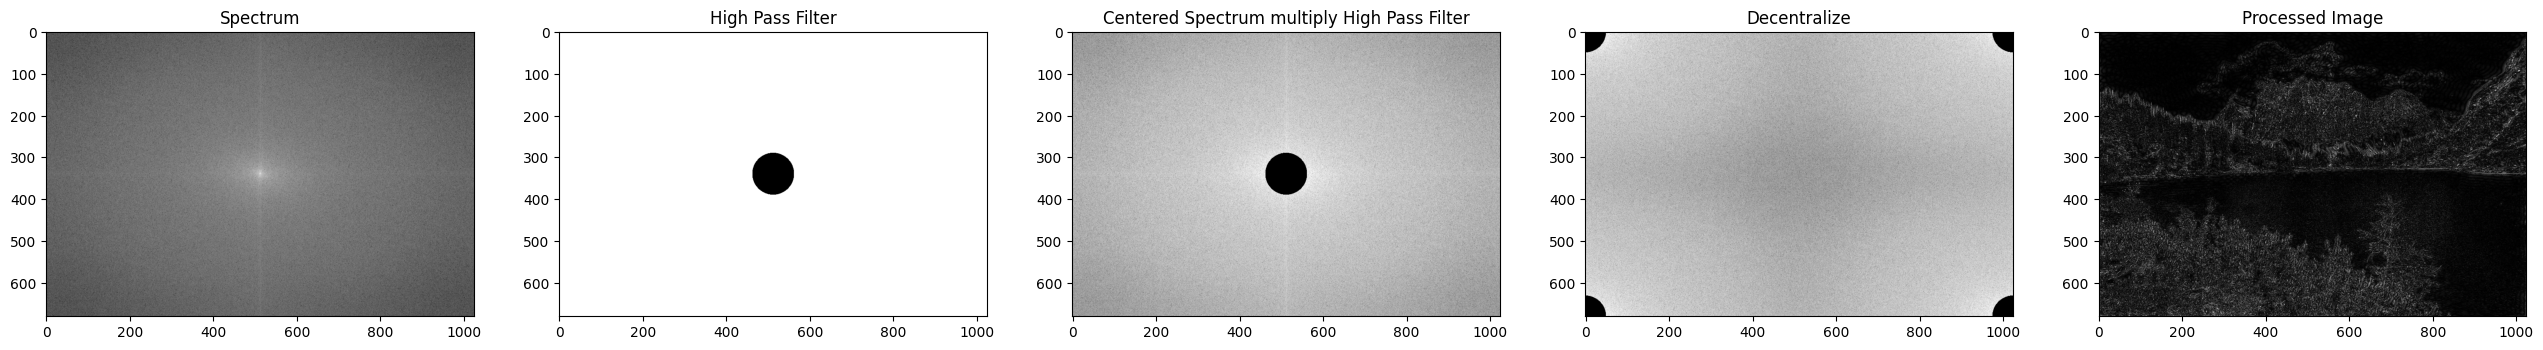

In [7]:
img = cv2.imread("data/image.jpg", 0)
original = np.fft.fft2(img)
center = np.fft.fftshift(original)

plt.figure(figsize=(6.4*5, 4.8*5), constrained_layout=False)

plt.subplot(151), plt.imshow(np.log(1+np.abs(center)), "gray"), plt.title("Spectrum")

HighPass = idealFilterHP(50,img.shape)
plt.subplot(152), plt.imshow(np.abs(HighPass), "gray"), plt.title("High Pass Filter")

HighPassCenter = center * idealFilterHP(50,img.shape)
plt.subplot(153), plt.imshow(np.log(1+np.abs(HighPassCenter)), "gray"), plt.title("Centered Spectrum multiply High Pass Filter")

HighPass = np.fft.ifftshift(HighPassCenter)
plt.subplot(154), plt.imshow(np.log(1+np.abs(HighPass)), "gray"), plt.title("Decentralize")

inverse_HighPass = np.fft.ifft2(HighPass)
plt.subplot(155), plt.imshow(np.abs(inverse_HighPass), "gray"), plt.title("Processed Image")

plt.show()

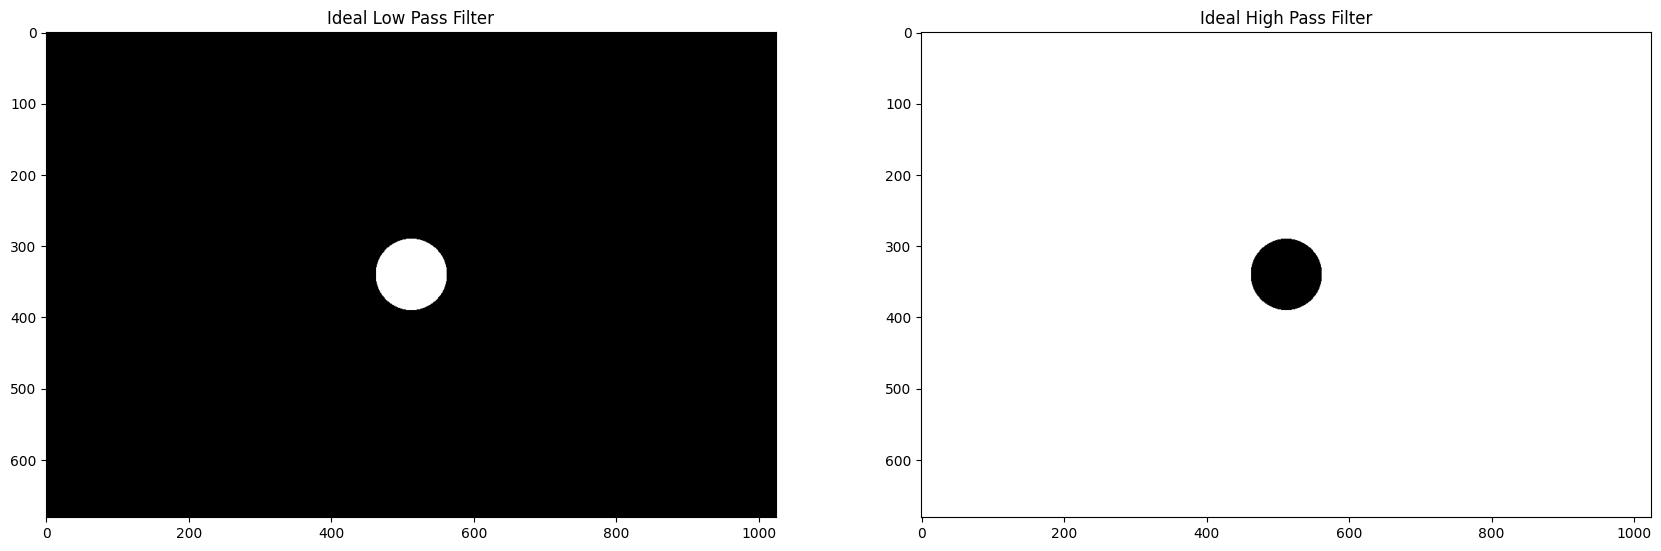

In [8]:
plt.figure(figsize=(6.4*5, 4.8*5), constrained_layout=False)

LowPass = idealFilterLP(50,img.shape)
plt.subplot(131), plt.imshow(LowPass, "gray"), plt.title("Ideal Low Pass Filter")

HighPass = idealFilterHP(50,img.shape)
plt.subplot(132), plt.imshow(HighPass, "gray"), plt.title("Ideal High Pass Filter")

plt.show()

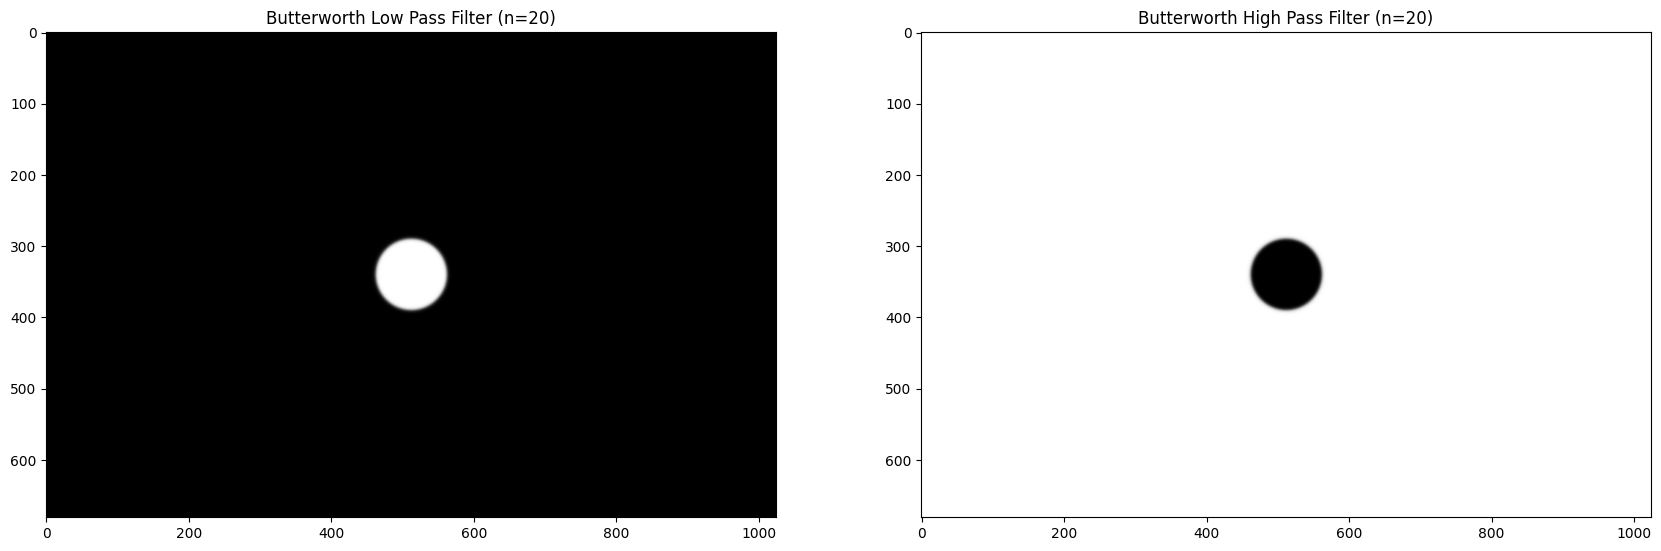

In [9]:
plt.figure(figsize=(6.4*5, 4.8*5), constrained_layout=False)

LowPass = butterworthLP(50,img.shape,20)
plt.subplot(131), plt.imshow(LowPass, "gray"), plt.title("Butterworth Low Pass Filter (n=20)")

HighPass = butterworthHP(50,img.shape,20)
plt.subplot(132), plt.imshow(HighPass, "gray"), plt.title("Butterworth High Pass Filter (n=20)")

plt.show()

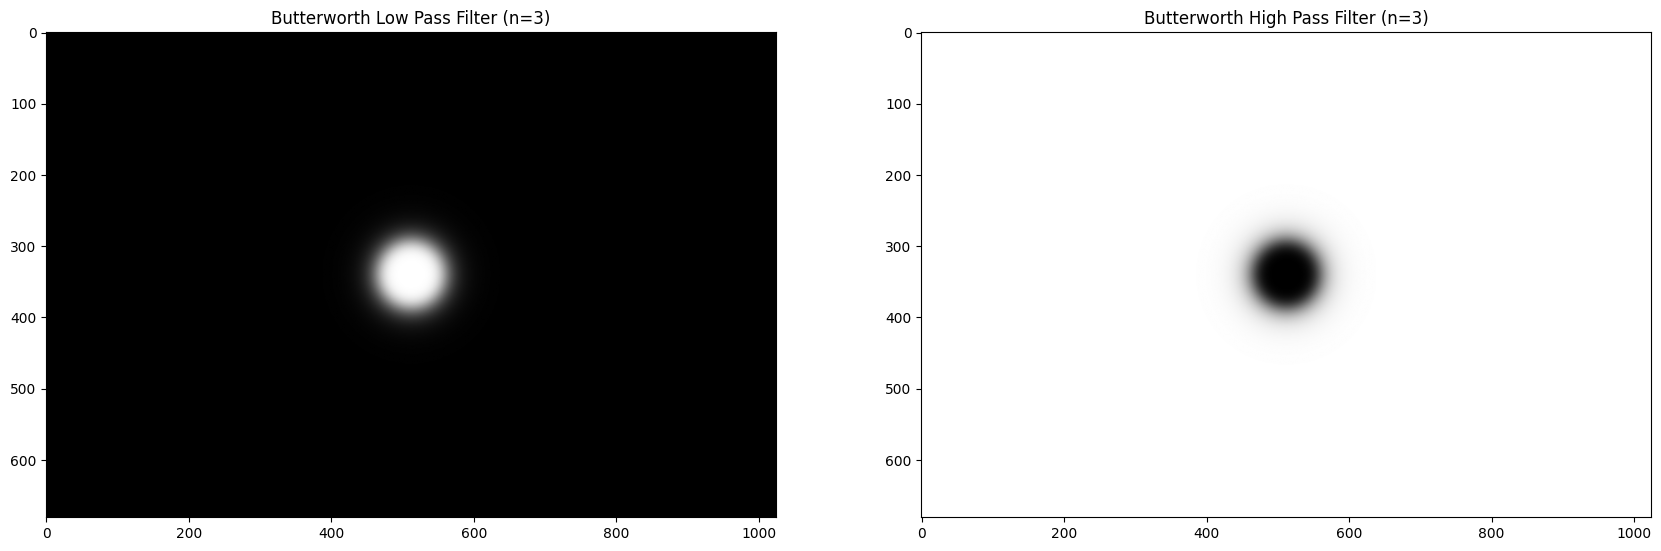

In [10]:
plt.figure(figsize=(6.4*5, 4.8*5), constrained_layout=False)

LowPass = butterworthLP(50,img.shape,3)
plt.subplot(131), plt.imshow(LowPass, "gray"), plt.title("Butterworth Low Pass Filter (n=3)")

HighPass = butterworthHP(50,img.shape,3)
plt.subplot(132), plt.imshow(HighPass, "gray"), plt.title("Butterworth High Pass Filter (n=3)")

plt.show()

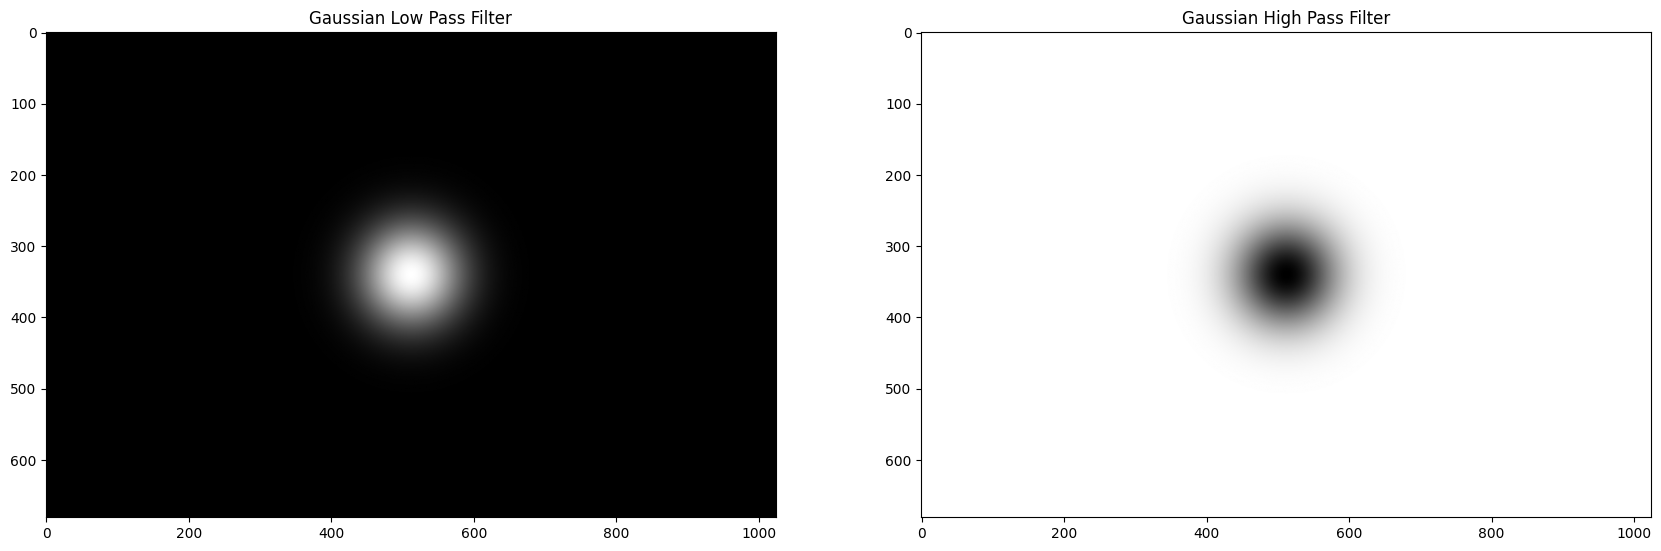

In [11]:
plt.figure(figsize=(6.4*5, 4.8*5), constrained_layout=False)

LowPass = gaussianLP(50,img.shape)
plt.subplot(131), plt.imshow(LowPass, "gray"), plt.title("Gaussian Low Pass Filter")

HighPass = gaussianHP(50,img.shape)
plt.subplot(132), plt.imshow(HighPass, "gray"), plt.title("Gaussian High Pass Filter")

plt.show()

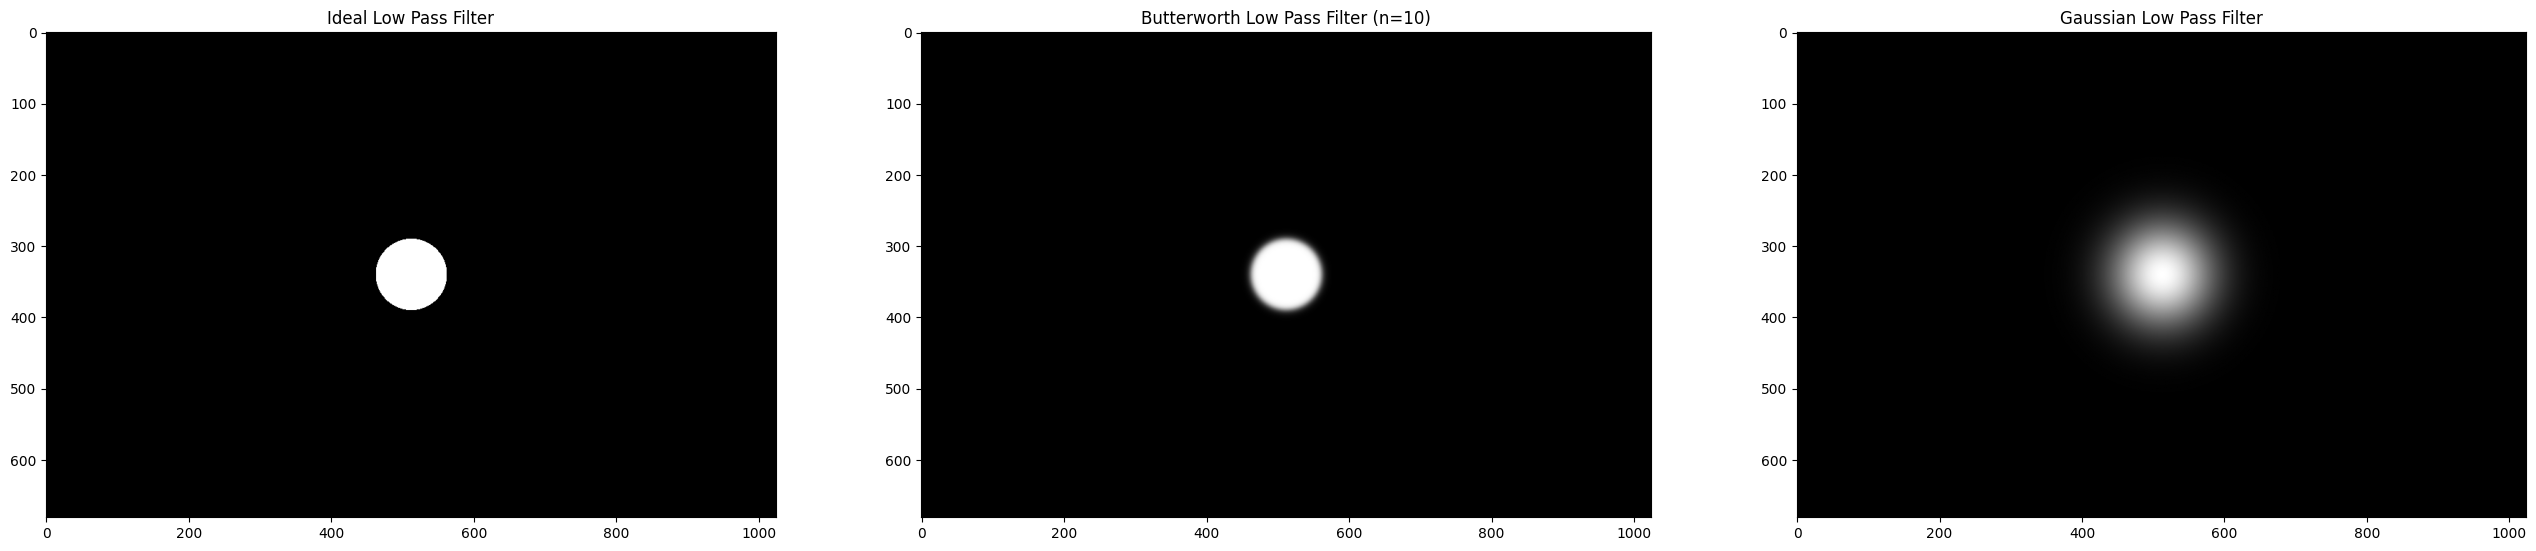

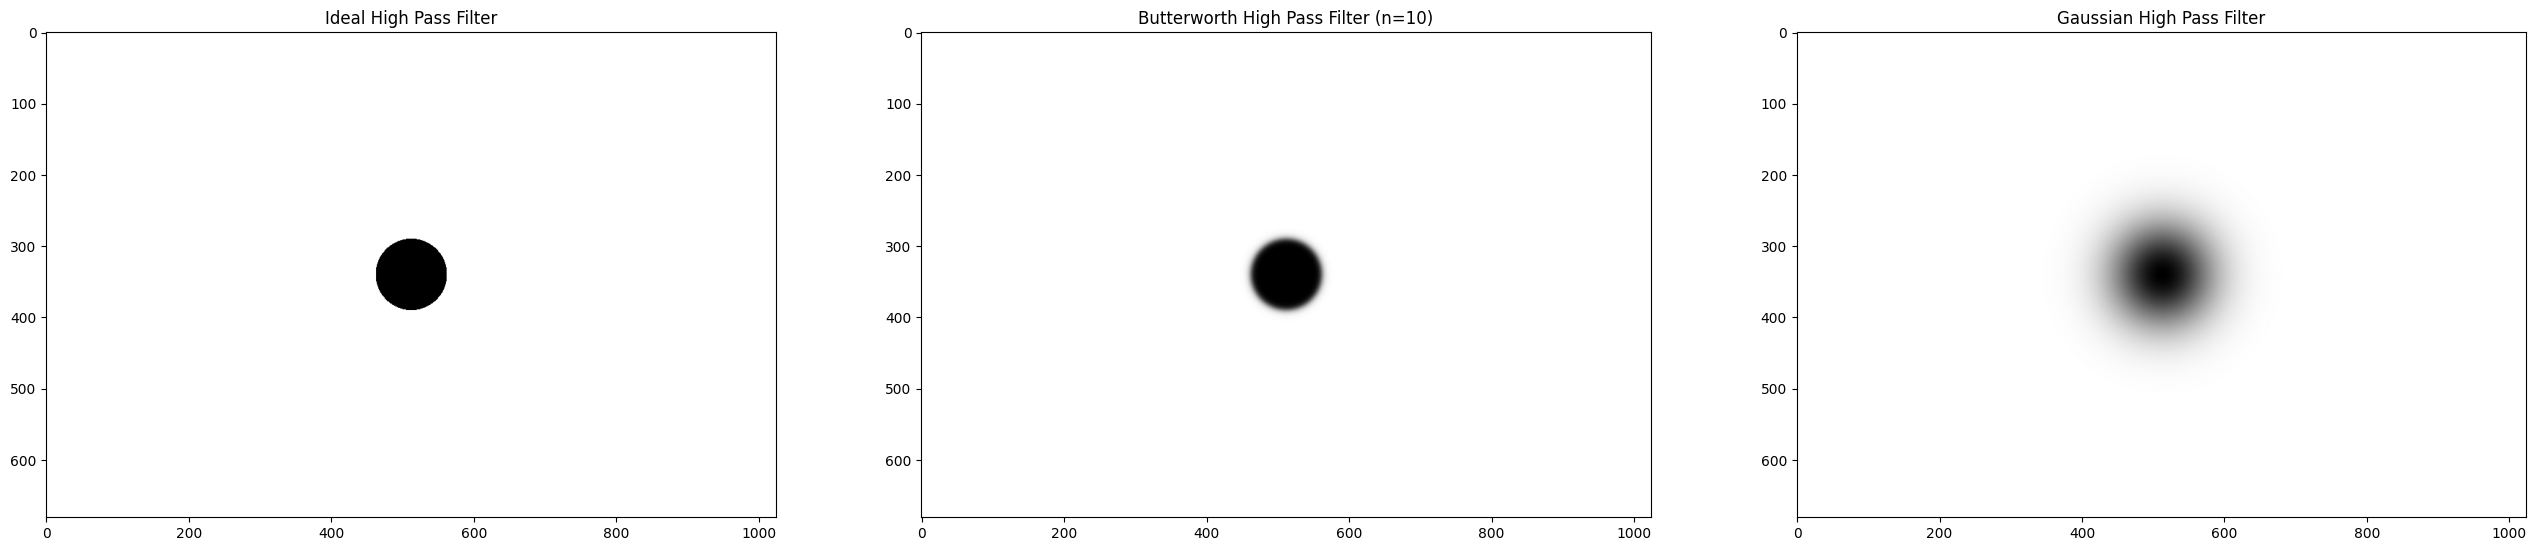

In [12]:
plt.figure(figsize=(6.4*5, 4.8*5), constrained_layout=False)

IdealLP = idealFilterLP(50,img.shape)
plt.subplot(131), plt.imshow(IdealLP, "gray"), plt.title("Ideal Low Pass Filter")

ButterLP = butterworthLP(50,img.shape,10)
plt.subplot(132), plt.imshow(ButterLP, "gray"), plt.title("Butterworth Low Pass Filter (n=10)")

GaussianLP = gaussianLP(50,img.shape)
plt.subplot(133), plt.imshow(GaussianLP, "gray"), plt.title("Gaussian Low Pass Filter")

plt.figure(figsize=(6.4*5, 4.8*5), constrained_layout=False)
IdealHP = idealFilterHP(50,img.shape)
plt.subplot(231), plt.imshow(IdealHP, "gray"), plt.title("Ideal High Pass Filter")

ButterHP = butterworthHP(50,img.shape,10)
plt.subplot(232), plt.imshow(ButterHP, "gray"), plt.title("Butterworth High Pass Filter (n=10)")

GaussianHP = gaussianHP(50,img.shape)
plt.subplot(233), plt.imshow(GaussianHP, "gray"), plt.title("Gaussian High Pass Filter")

plt.show()

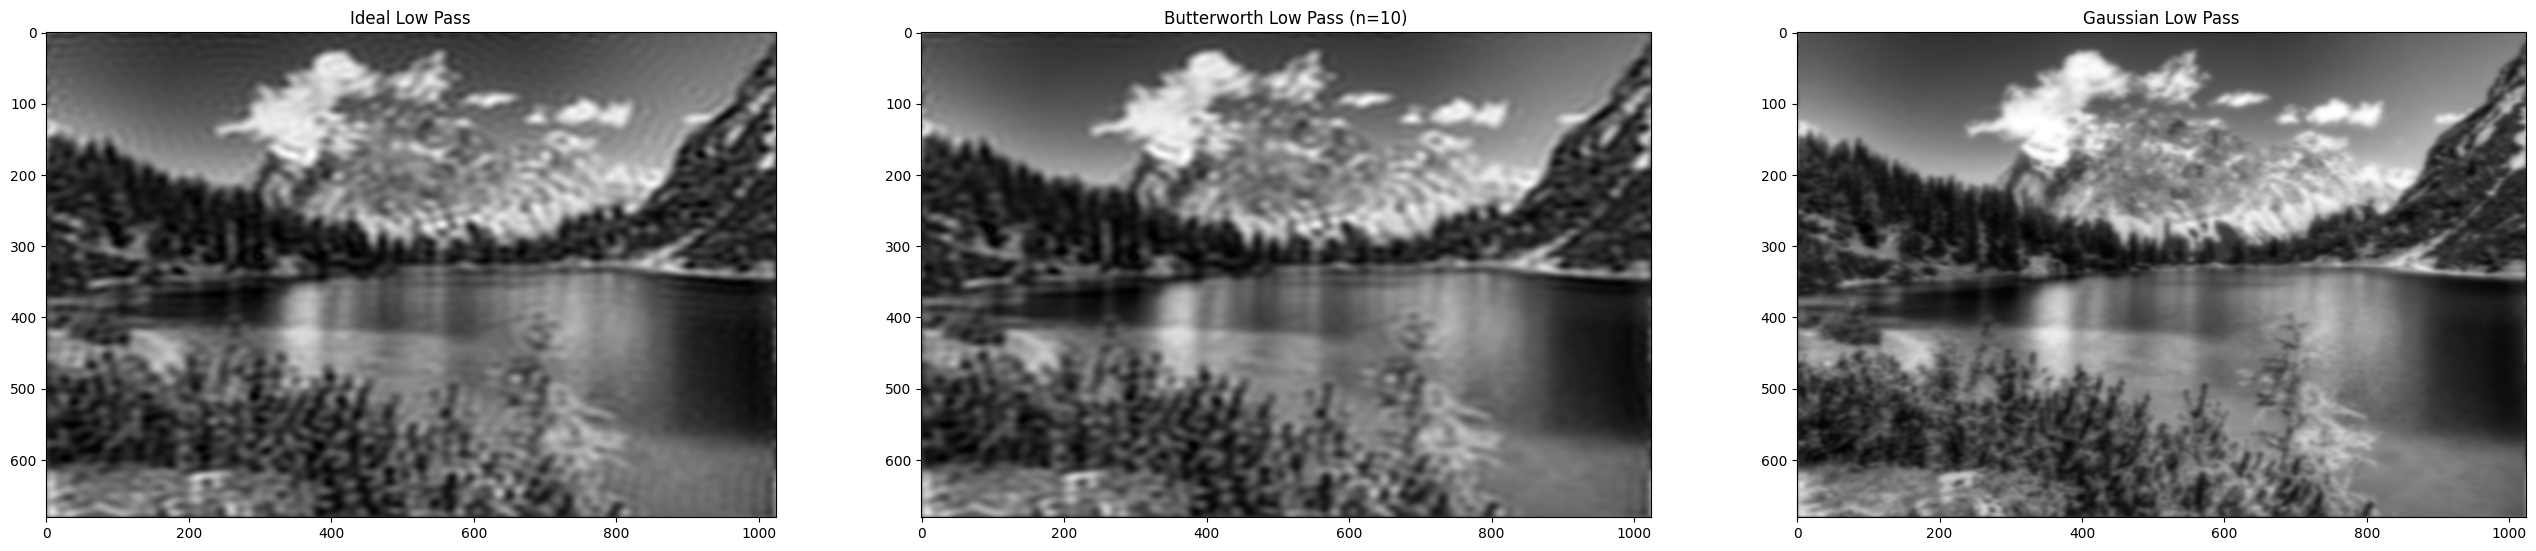

In [13]:
img = cv2.imread("data/image.jpg", 0)
original = np.fft.fft2(img)
center = np.fft.fftshift(original)

plt.figure(figsize=(6.4*5, 4.8*5), constrained_layout=False)

LowPassCenter = center * idealFilterLP(50,img.shape)
LowPass = np.fft.ifftshift(LowPassCenter)
inverse_LowPass = np.fft.ifft2(LowPass)
plt.subplot(131), plt.imshow(np.abs(inverse_LowPass), "gray"), plt.title("Ideal Low Pass")

LowPassCenter = center * butterworthLP(50,img.shape,10)
LowPass = np.fft.ifftshift(LowPassCenter)
inverse_LowPass = np.fft.ifft2(LowPass)
plt.subplot(132), plt.imshow(np.abs(inverse_LowPass), "gray"), plt.title("Butterworth Low Pass (n=10)")

LowPassCenter = center * gaussianLP(50,img.shape)
LowPass = np.fft.ifftshift(LowPassCenter)
inverse_LowPass = np.fft.ifft2(LowPass)
plt.subplot(133), plt.imshow(np.abs(inverse_LowPass), "gray"), plt.title("Gaussian Low Pass")

plt.show()

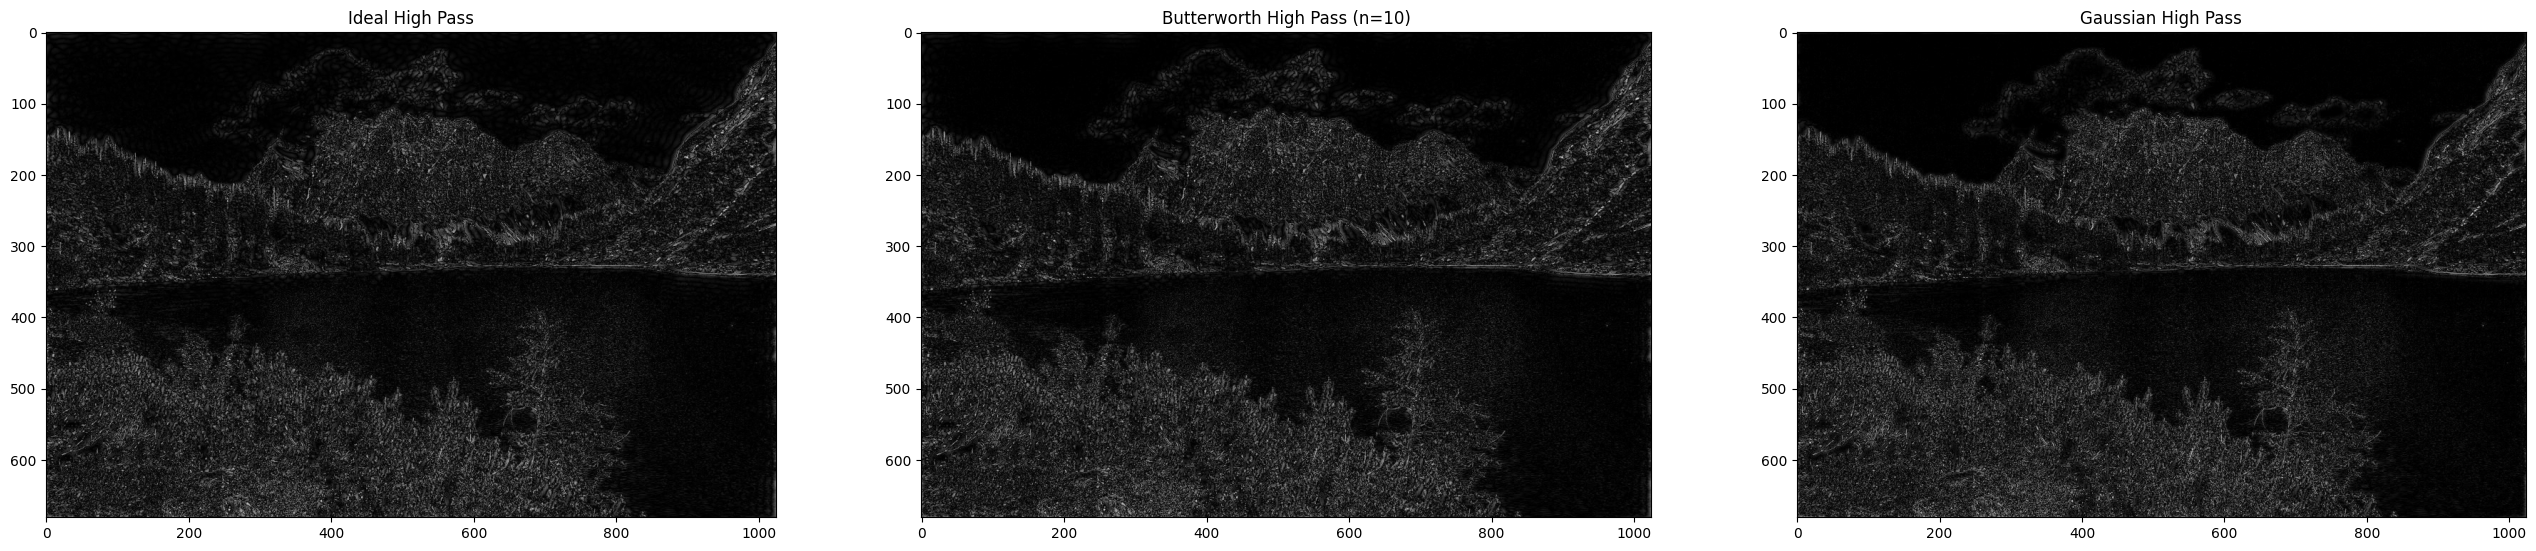

In [14]:
img = cv2.imread("data/image.jpg", 0)
original = np.fft.fft2(img)
center = np.fft.fftshift(original)

plt.figure(figsize=(6.4*5, 4.8*5), constrained_layout=False)

HighPassCenter = center * idealFilterHP(50,img.shape)
HighPass = np.fft.ifftshift(HighPassCenter)
inverse_HighPass = np.fft.ifft2(HighPass)
plt.subplot(131), plt.imshow(np.abs(inverse_HighPass), "gray"), plt.title("Ideal High Pass")

HighPassCenter = center * butterworthHP(50,img.shape,10)
HighPass = np.fft.ifftshift(HighPassCenter)
inverse_HighPass = np.fft.ifft2(HighPass)
plt.subplot(132), plt.imshow(np.abs(inverse_HighPass), "gray"), plt.title("Butterworth High Pass (n=10)")

HighPassCenter = center * gaussianHP(50,img.shape)
HighPass = np.fft.ifftshift(HighPassCenter)
inverse_HighPass = np.fft.ifft2(HighPass)
plt.subplot(133), plt.imshow(np.abs(inverse_HighPass), "gray"), plt.title("Gaussian High Pass")

plt.show()

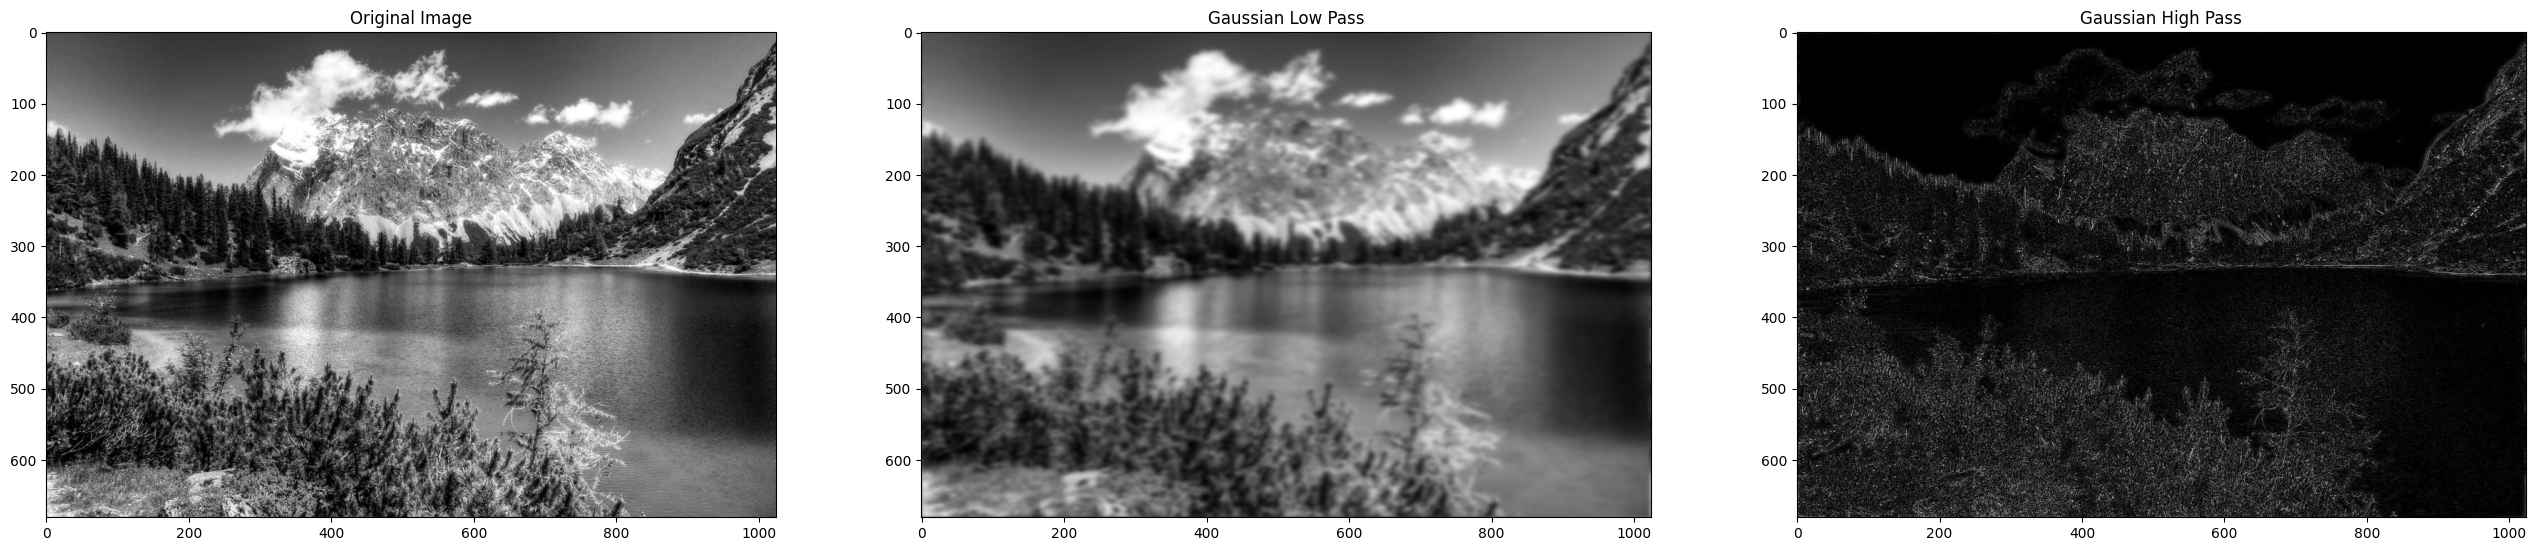

In [15]:
img = cv2.imread("data/image.jpg", 0)
original = np.fft.fft2(img)
center = np.fft.fftshift(original)

plt.figure(figsize=(6.4*5, 4.8*5), constrained_layout=False)

plt.subplot(131), plt.imshow(img, "gray"), plt.title("Original Image")

LowPassCenter = center * gaussianLP(50,img.shape)
LowPass = np.fft.ifftshift(LowPassCenter)
inverse_LowPass = np.fft.ifft2(LowPass)
plt.subplot(132), plt.imshow(np.abs(inverse_LowPass), "gray"), plt.title("Gaussian Low Pass")

HighPassCenter = center * gaussianHP(50,img.shape)
HighPass = np.fft.ifftshift(HighPassCenter)
inverse_HighPass = np.fft.ifft2(HighPass)
plt.subplot(133), plt.imshow(np.abs(inverse_HighPass), "gray"), plt.title("Gaussian High Pass")

plt.show()

# > Solution

## 1 - Low-Pass Filtering in the Fourier Domain for Image Enhancement

**Research Background**

The Fourier transform is a fundamental mathematical tool in digital image processing that decomposes an image into its frequency components, enabling manipulation in the frequency domain (Gonzalez & Woods, 2018). This transformation represents images as a combination of sinusoidal waves of different frequencies, where low frequencies correspond to smooth regions and gradual intensity variations, while high frequencies represent edges, fine details, and noise (Burger & Burge, 2016).

Low-pass filtering in the frequency domain is a technique used to attenuate high-frequency components while preserving low frequencies, resulting in image smoothing and noise reduction. This approach is particularly effective for removing high-frequency noise while maintaining the overall structure of the image (Pratt, 2007). The process involves transforming the image to the frequency domain using the Fast Fourier Transform (FFT), multiplying by a low-pass filter transfer function, and applying the inverse transform to return to the spatial domain (Gonzalez & Woods, 2018).

* **Ideal Low-Pass Filter (ILPF)**

The Ideal Low-Pass Filter (ILPF) implements a sharp cutoff at a specified frequency threshold D₀, completely eliminating all frequencies beyond this radius while preserving those within it (Gonzalez & Woods, 2018). Although conceptually simple, the ILPF produces ringing artifacts known as the Gibbs phenomenon due to its discontinuous transfer function in the frequency domain (Pratt, 2007).

* **Butterworth Low-Pass Filter (BLPF)**

The Butterworth Low-Pass Filter (BLPF) provides a smooth transition between preserved and attenuated frequencies, controlled by the filter order n and cutoff frequency D₀ (Burger & Burge, 2016). This filter avoids the ringing artifacts of the ideal filter while maintaining effective frequency attenuation. Higher-order Butterworth filters approach the ideal filter's sharp cutoff but with reduced artifacts (Gonzalez & Woods, 2018).

* **Gaussian Low-Pass Filter (GLPF)**

The Gaussian Low-Pass Filter (GLPF) uses a Gaussian function for smooth frequency attenuation, characterized by its standard deviation σ or cutoff frequency D₀ (Jain, 1989). The Gaussian filter is theoretically optimal because its Fourier transform is also Gaussian, ensuring no ringing artifacts in either domain. This property makes it particularly suitable for applications requiring artifact-free smoothing (Pratt, 2007).

**Application: Noise Reduction in Photography**

Low-pass filtering in the frequency domain is extensively applied in digital photography for noise reduction, particularly in images captured under low-light conditions where sensor noise is prominent (Pratt, 2007). High-frequency noise artifacts, manifesting as random intensity variations across pixels, significantly degrade image quality and visual appeal. By attenuating these high-frequency noise components while preserving low-frequency structural information, frequency domain filters effectively enhance image quality for subsequent processing, analysis, or display (Gonzalez & Woods, 2018).

The choice of filter type depends on specific application requirements: Gaussian filters provide optimal performance for general noise reduction due to their artifact-free characteristics, Butterworth filters offer controlled smoothing with adjustable transition slopes, and ideal filters are reserved for applications requiring sharp frequency cutoffs despite the trade-off of ringing artifacts (Burger & Burge, 2016). The cutoff frequency parameter must be carefully selected to balance noise suppression and detail preservation, typically determined through empirical testing or automated optimization methods.

**References**

- Burger, W., & Burge, M. J. (2016). *Digital image processing: An algorithmic introduction using Java* (2nd ed.). Springer.

- Gonzalez, R. C., & Woods, R. E. (2018). *Digital image processing* (4th ed.). Pearson.

- Jain, A. K. (1989). *Fundamentals of digital image processing*. Prentice Hall.

- Pratt, W. K. (2007). *Digital image processing: PIXE and fundamentals* (4th ed.). Wiley-Interscience.

In [16]:
def create_ideal_lpf(shape, cutoff):
    """
    Create Ideal Low-Pass Filter
    Args:
        shape: tuple (rows, cols)
        cutoff: cutoff frequency D0
    Returns:
        Filter mask
    """
    rows, cols = shape
    crow, ccol = rows // 2, cols // 2
    
    # Create distance matrix from center
    u = np.arange(rows)
    v = np.arange(cols)
    u, v = np.meshgrid(u - crow, v - ccol, indexing='ij')
    D = np.sqrt(u**2 + v**2)
    
    # Ideal filter: sharp cutoff
    H = np.zeros(shape, dtype=np.float32)
    H[D <= cutoff] = 1
    
    return H

In [17]:
def create_butterworth_lpf(shape, cutoff, order=2):
    """
    Create Butterworth Low-Pass Filter
    Args:
        shape: tuple (rows, cols)
        cutoff: cutoff frequency D0
        order: filter order n
    Returns:
        Filter mask
    """
    rows, cols = shape
    crow, ccol = rows // 2, cols // 2
    
    u = np.arange(rows)
    v = np.arange(cols)
    u, v = np.meshgrid(u - crow, v - ccol, indexing='ij')
    D = np.sqrt(u**2 + v**2)
    
    # Butterworth filter: smooth transition
    H = 1 / (1 + (D / cutoff)**(2 * order))
    
    return H

In [18]:
def create_gaussian_lpf(shape, cutoff):
    """
    Create Gaussian Low-Pass Filter
    Args:
        shape: tuple (rows, cols)
        cutoff: cutoff frequency D0 (related to sigma)
    Returns:
        Filter mask
    """
    rows, cols = shape
    crow, ccol = rows // 2, cols // 2
    
    u = np.arange(rows)
    v = np.arange(cols)
    u, v = np.meshgrid(u - crow, v - ccol, indexing='ij')
    D = np.sqrt(u**2 + v**2)
    
    # Gaussian filter: no ringing artifacts
    H = np.exp(-(D**2) / (2 * (cutoff**2)))
    
    return H

In [19]:
def apply_frequency_filter(image, filter_mask):
    """
    Apply frequency domain filter to image
    Args:
        image: grayscale image
        filter_mask: frequency domain filter
    Returns:
        Filtered image
    """
    # Fourier transform
    f_transform = np.fft.fft2(image)
    f_shift = np.fft.fftshift(f_transform)
    
    # Apply filter
    filtered_shift = f_shift * filter_mask
    
    # Inverse transform
    f_ishift = np.fft.ifftshift(filtered_shift)
    img_back = np.fft.ifft2(f_ishift)
    img_back = np.real(img_back)
    
    return np.clip(img_back, 0, 255).astype(np.uint8)

Image shape: (4024, 6048)
Maximum frequency distance: 3632.18
Try cutoffs: 72, 181, 363


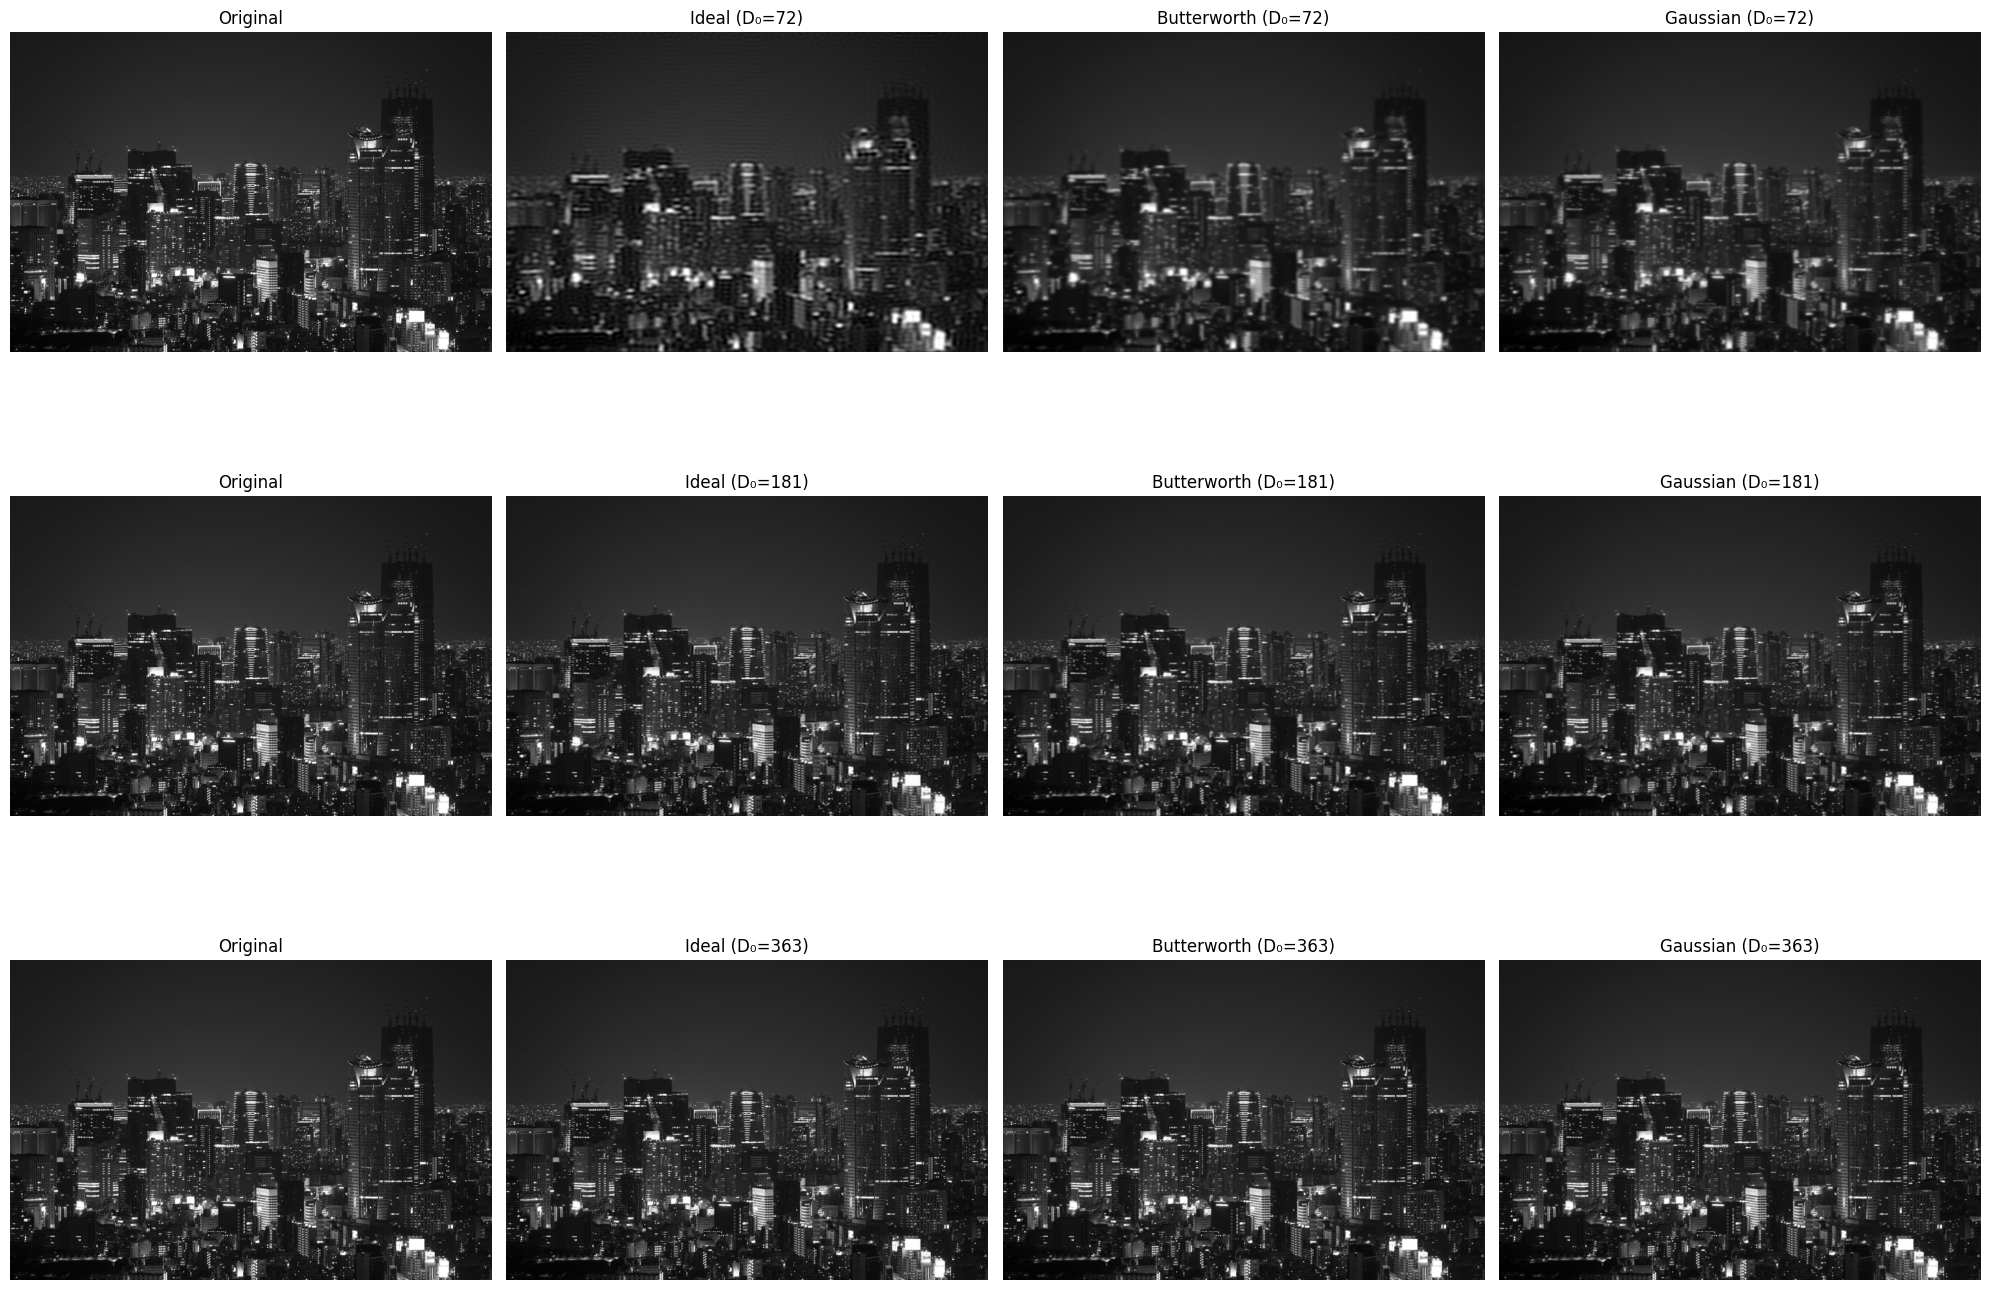

In [20]:
# https://www.freepik.es/foto-gratis/angulo-alto-edificios-hermosos-noche_27643048.htm#fromView=keyword&page=1&position=1&uuid=33ad5c33-984c-400e-a832-7546d58d7b48&query=Background+city+night
img = cv2.imread('data/city-night.jpg')
gray_image = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# First, checking the image size
print(f"Image shape: {gray_image.shape}")

# Calculate the maximum distance
rows, cols = gray_image.shape
max_distance = np.sqrt((rows/2)**2 + (cols/2)**2)
print(f"Maximum frequency distance: {max_distance:.2f}")

# Try different cutoffs (as % of the maximum distance)
cutoff_freq_low = int(0.02 * max_distance)    # 10% - blurry
cutoff_freq_medium = int(0.05 * max_distance)  # 30% - moderate blur
cutoff_freq_high = int(0.1 * max_distance)    # 50% - light blur

print(f"Try cutoffs: {cutoff_freq_low}, {cutoff_freq_medium}, {cutoff_freq_high}")

# Experiment with multiple values
cutoff_values = [cutoff_freq_low, cutoff_freq_medium, cutoff_freq_high]

fig, axes = plt.subplots(len(cutoff_values), 4, figsize=(20, 5*len(cutoff_values)))

for idx, cutoff in enumerate(cutoff_values):
    # Create filters
    ideal_f = create_ideal_lpf(gray_image.shape, cutoff)
    butter_f = create_butterworth_lpf(gray_image.shape, cutoff, order=2)
    gauss_f = create_gaussian_lpf(gray_image.shape, cutoff)
    
    # Apply filters
    img_ideal = apply_frequency_filter(gray_image, ideal_f)
    img_butter = apply_frequency_filter(gray_image, butter_f)
    img_gauss = apply_frequency_filter(gray_image, gauss_f)
    
    # Plot
    axes[idx, 0].imshow(gray_image, cmap='gray')
    axes[idx, 0].set_title('Original')
    axes[idx, 0].axis('off')

    axes[idx, 1].imshow(img_ideal, cmap='gray')
    axes[idx, 1].set_title(f'Ideal (D₀={cutoff})')
    axes[idx, 1].axis('off')
    
    axes[idx, 2].imshow(img_butter, cmap='gray')
    axes[idx, 2].set_title(f'Butterworth (D₀={cutoff})')
    axes[idx, 2].axis('off')
    
    axes[idx, 3].imshow(img_gauss, cmap='gray')
    axes[idx, 3].set_title(f'Gaussian (D₀={cutoff})')
    axes[idx, 3].axis('off')
    
plt.tight_layout()
plt.show()

The experimental results demonstrate the progressive effects of low-pass filtering across three different cutoff frequencies (D₀=72, D₀=181, and D₀=363) applied to a nocturnal urban scene. The image dimensions yield a maximum frequency distance of approximately 3632 pixels, meaning the tested cutoff values represent approximately 2%, 5%, and 10% of the maximum frequency radius, respectively.

**Effect of Cutoff Frequency on Smoothing Intensity**

At D₀=72 (2% of maximum frequency), all three filters produce substantial smoothing effects, effectively suppressing high-frequency components corresponding to fine details, edges, and sensor noise. The aggressive attenuation results in visible blurring across the entire image, with building textures and small architectural features becoming significantly less defined. This cutoff value removes approximately 98% of the frequency spectrum, retaining only the lowest frequency components that represent the coarse structure and overall luminance distribution of the scene.

At D₀=181 (5% of maximum frequency), the filtering effect becomes more moderate. While noise reduction remains evident, particularly in the dark sky regions and uniform building surfaces, the overall structural information of the cityscape is better preserved. Individual buildings maintain recognizable shapes, and major architectural features remain visible, though fine details such as window patterns and small structural elements show reduced clarity.

At D₀=363 (10% of maximum frequency), the smoothing becomes subtle, approaching the visual appearance of the original image. At this cutoff, the filters primarily attenuate the highest frequency noise components while preserving most of the image detail. The result appears as gentle noise reduction with minimal impact on edge definition or textural information.

**Comparative Analysis of Filter Types**

The theoretical distinctions between the three filter types become apparent primarily at the lowest cutoff frequency (D₀=72). The ideal low-pass filter, characterized by its sharp discontinuous transition at the cutoff radius, introduces subtle ringing artifacts visible as slight halos around high-contrast edges, particularly near the bright building lights against the dark sky background. This Gibbs phenomenon arises from the filter's rectangular frequency response, which cannot be perfectly realized in the spatial domain without infinite extent (Gonzalez & Woods, 2018).

The Butterworth filter with second-order configuration exhibits a smoother transition between passed and rejected frequencies, following the transfer function H(u,v) = 1/[1 + (D/D₀)^(2n)]. This gradual rolloff eliminates the ringing artifacts observed in the ideal filter while maintaining effective high-frequency attenuation. The resulting images appear more natural, with smooth intensity transitions and no perceptible oscillatory artifacts.

The Gaussian low-pass filter produces the smoothest results among the three approaches. Its unique property of maintaining Gaussian shape in both frequency and spatial domains ensures complete absence of ringing artifacts regardless of cutoff frequency. The filter's transfer function H(u,v) = e^(-D²/2D₀²) provides the most gradual frequency transition, resulting in the most visually pleasing smoothing effect with uniform noise suppression across all image regions.

**Practical Implications**

The selection of appropriate cutoff frequency represents a critical trade-off between noise reduction and detail preservation. Lower cutoff values (D₀ < 5% of maximum frequency) provide aggressive noise suppression suitable for heavily degraded images but at the cost of significant detail loss. Moderate values (D₀ ≈ 5-10%) offer balanced performance for typical noise reduction applications, while higher values (D₀ > 10%) produce minimal smoothing appropriate for subtle enhancement tasks.

For the night photography application examined here, the intermediate cutoff frequency (D₀=181) with a Butterworth or Gaussian filter provides optimal results, effectively reducing sensor noise in dark regions while maintaining architectural detail and edge definition. The near-identical appearance of all three filters at higher cutoff frequencies (D₀=363) confirms that filter-specific artifacts only manifest when significant frequency attenuation occurs, validating the theoretical expectation that differences between filter types become negligible when most frequency components are preserved.

## 2 - High-Pass Filtering in the Fourier Domain for Image Enhancement

**Research Background**

While low-pass filters attenuate high-frequency components to reduce noise and smooth images, high-pass filters perform the complementary operation by suppressing low frequencies while preserving high frequencies (Gonzalez & Woods, 2018). High-frequency components in an image correspond to sharp transitions, edges, fine details, and texture, making high-pass filtering a fundamental technique for edge detection, sharpening, and feature enhancement applications (Burger & Burge, 2016).

High-pass filtering in the frequency domain is implemented by attenuating frequency components near the origin of the Fourier transform, where low frequencies concentrate, while allowing higher frequencies to pass through with minimal attenuation (Pratt, 2007). The mathematical relationship between low-pass and high-pass filters is straightforward: a high-pass filter transfer function can be obtained by subtracting a low-pass filter from unity, expressed as H_HP(u,v) = 1 - H_LP(u,v), where H_LP represents the corresponding low-pass filter transfer function (Gonzalez & Woods, 2018).

* **Ideal High-Pass Filter (IHPF)**

The Ideal High-Pass Filter (IHPF) completely blocks all frequencies within a radius D₀ from the origin while preserving all frequencies beyond this threshold (Gonzalez & Woods, 2018). The transfer function is defined as H(u,v) = 0 if D(u,v) ≤ D₀, and H(u,v) = 1 if D(u,v) > D₀, where D(u,v) represents the distance from the frequency domain center. Similar to its low-pass counterpart, the IHPF produces ringing artifacts due to its sharp discontinuity, though these artifacts manifest differently in edge-enhanced images (Pratt, 2007).

* **Butterworth High-Pass Filter (BHPF)**

The Butterworth High-Pass Filter (BHPF) provides a smooth transition between attenuated and preserved frequencies, controlled by the cutoff frequency D₀ and filter order n (Burger & Burge, 2016). The transfer function follows H(u,v) = 1/[1 + (D₀/D(u,v))^(2n)], which approaches zero for low frequencies and unity for high frequencies. Higher-order Butterworth filters produce sharper transitions while maintaining reduced ringing compared to ideal filters (Gonzalez & Woods, 2018).

* **Gaussian High-Pass Filter (GHPF)**

The Gaussian High-Pass Filter (GHPF) employs a Gaussian function for smooth frequency attenuation with transfer function H(u,v) = 1 - e^(-D²/2D₀²) (Jain, 1989). The Gaussian high-pass filter inherits the desirable property of its low-pass counterpart: complete absence of ringing artifacts in both frequency and spatial domains. This characteristic makes it particularly suitable for applications requiring clean edge enhancement without introducing spurious oscillations (Pratt, 2007).

**Application: Medical Image Enhancement for Diagnostic Imaging**

A critical application of high-pass filtering is in medical radiography enhancement, particularly for chest X-rays and bone structure visualization. Medical images often suffer from low contrast between anatomical structures due to overlapping tissues and varying densities (Gonzalez & Woods, 2018). High-pass filtering enhances edges and fine details such as bone fractures, tissue boundaries, and vascular structures by suppressing the slowly varying background intensity while emphasizing rapid intensity transitions that correspond to anatomical features (Burger & Burge, 2016).

In chest radiography, high-pass filtering can reveal subtle lung nodules, rib fractures, and pneumothorax that might be obscured in the original image due to the superposition of soft tissue structures. The selection of cutoff frequency D₀ is crucial: excessively low values may introduce excessive noise amplification, while overly high values may fail to enhance diagnostically relevant features. Gaussian high-pass filters are often preferred in clinical applications due to their artifact-free enhancement, ensuring that diagnostically important edges are emphasized without introducing false features that could lead to misdiagnosis (Pratt, 2007).

**References**

- Burger, W., & Burge, M. J. (2016). *Digital image processing: An algorithmic introduction using Java* (2nd ed.). Springer.

- Gonzalez, R. C., & Woods, R. E. (2018). *Digital image processing* (4th ed.). Pearson.

- Jain, A. K. (1989). *Fundamentals of digital image processing*. Prentice Hall.

- Pratt, W. K. (2007). *Digital image processing: PIXE and fundamentals* (4th ed.). Wiley-Interscience.

In [21]:
def create_ideal_hpf(shape, cutoff):
    """
    Create Ideal High-Pass Filter
    Args:
        shape: tuple (rows, cols)
        cutoff: cutoff frequency D0
    Returns:
        Filter mask
    """
    rows, cols = shape
    crow, ccol = rows // 2, cols // 2
    
    # Create distance matrix from center
    u = np.arange(rows)
    v = np.arange(cols)
    u, v = np.meshgrid(u - crow, v - ccol, indexing='ij')
    D = np.sqrt(u**2 + v**2)
    
    # Ideal high-pass filter: H = 1 - H_lowpass
    H = np.ones(shape, dtype=np.float32)
    H[D <= cutoff] = 0
    
    return H

In [22]:
def create_butterworth_hpf(shape, cutoff, order=2):
    """
    Create Butterworth High-Pass Filter
    Args:
        shape: tuple (rows, cols)
        cutoff: cutoff frequency D0
        order: filter order n
    Returns:
        Filter mask
    """
    rows, cols = shape
    crow, ccol = rows // 2, cols // 2
    
    u = np.arange(rows)
    v = np.arange(cols)
    u, v = np.meshgrid(u - crow, v - ccol, indexing='ij')
    D = np.sqrt(u**2 + v**2)
    
    # Avoid division by zero
    D[D == 0] = 1e-10
    
    # Butterworth high-pass filter
    H = 1 / (1 + (cutoff / D)**(2 * order))
    
    return H

In [23]:
def create_gaussian_hpf(shape, cutoff):
    """
    Create Gaussian High-Pass Filter
    Args:
        shape: tuple (rows, cols)
        cutoff: cutoff frequency D0
    Returns:
        Filter mask
    """
    rows, cols = shape
    crow, ccol = rows // 2, cols // 2
    
    u = np.arange(rows)
    v = np.arange(cols)
    u, v = np.meshgrid(u - crow, v - ccol, indexing='ij')
    D = np.sqrt(u**2 + v**2)
    
    # Gaussian high-pass filter: H = 1 - H_lowpass
    H = 1 - np.exp(-(D**2) / (2 * (cutoff**2)))
    
    return H

In [24]:
def apply_frequency_filter(image, filter_mask):
    """
    Apply frequency domain filter to image
    Args:
        image: grayscale image
        filter_mask: frequency domain filter
    Returns:
        Filtered image
    """
    # Fourier transform
    f_transform = np.fft.fft2(image)
    f_shift = np.fft.fftshift(f_transform)
    
    # Apply filter
    filtered_shift = f_shift * filter_mask
    
    # Inverse transform
    f_ishift = np.fft.ifftshift(filtered_shift)
    img_back = np.fft.ifft2(f_ishift)
    img_back = np.real(img_back)
    
    return img_back

Image shape: (240, 210)
Maximum frequency distance: 159.45
Cutoff frequencies: 1, 4, 7


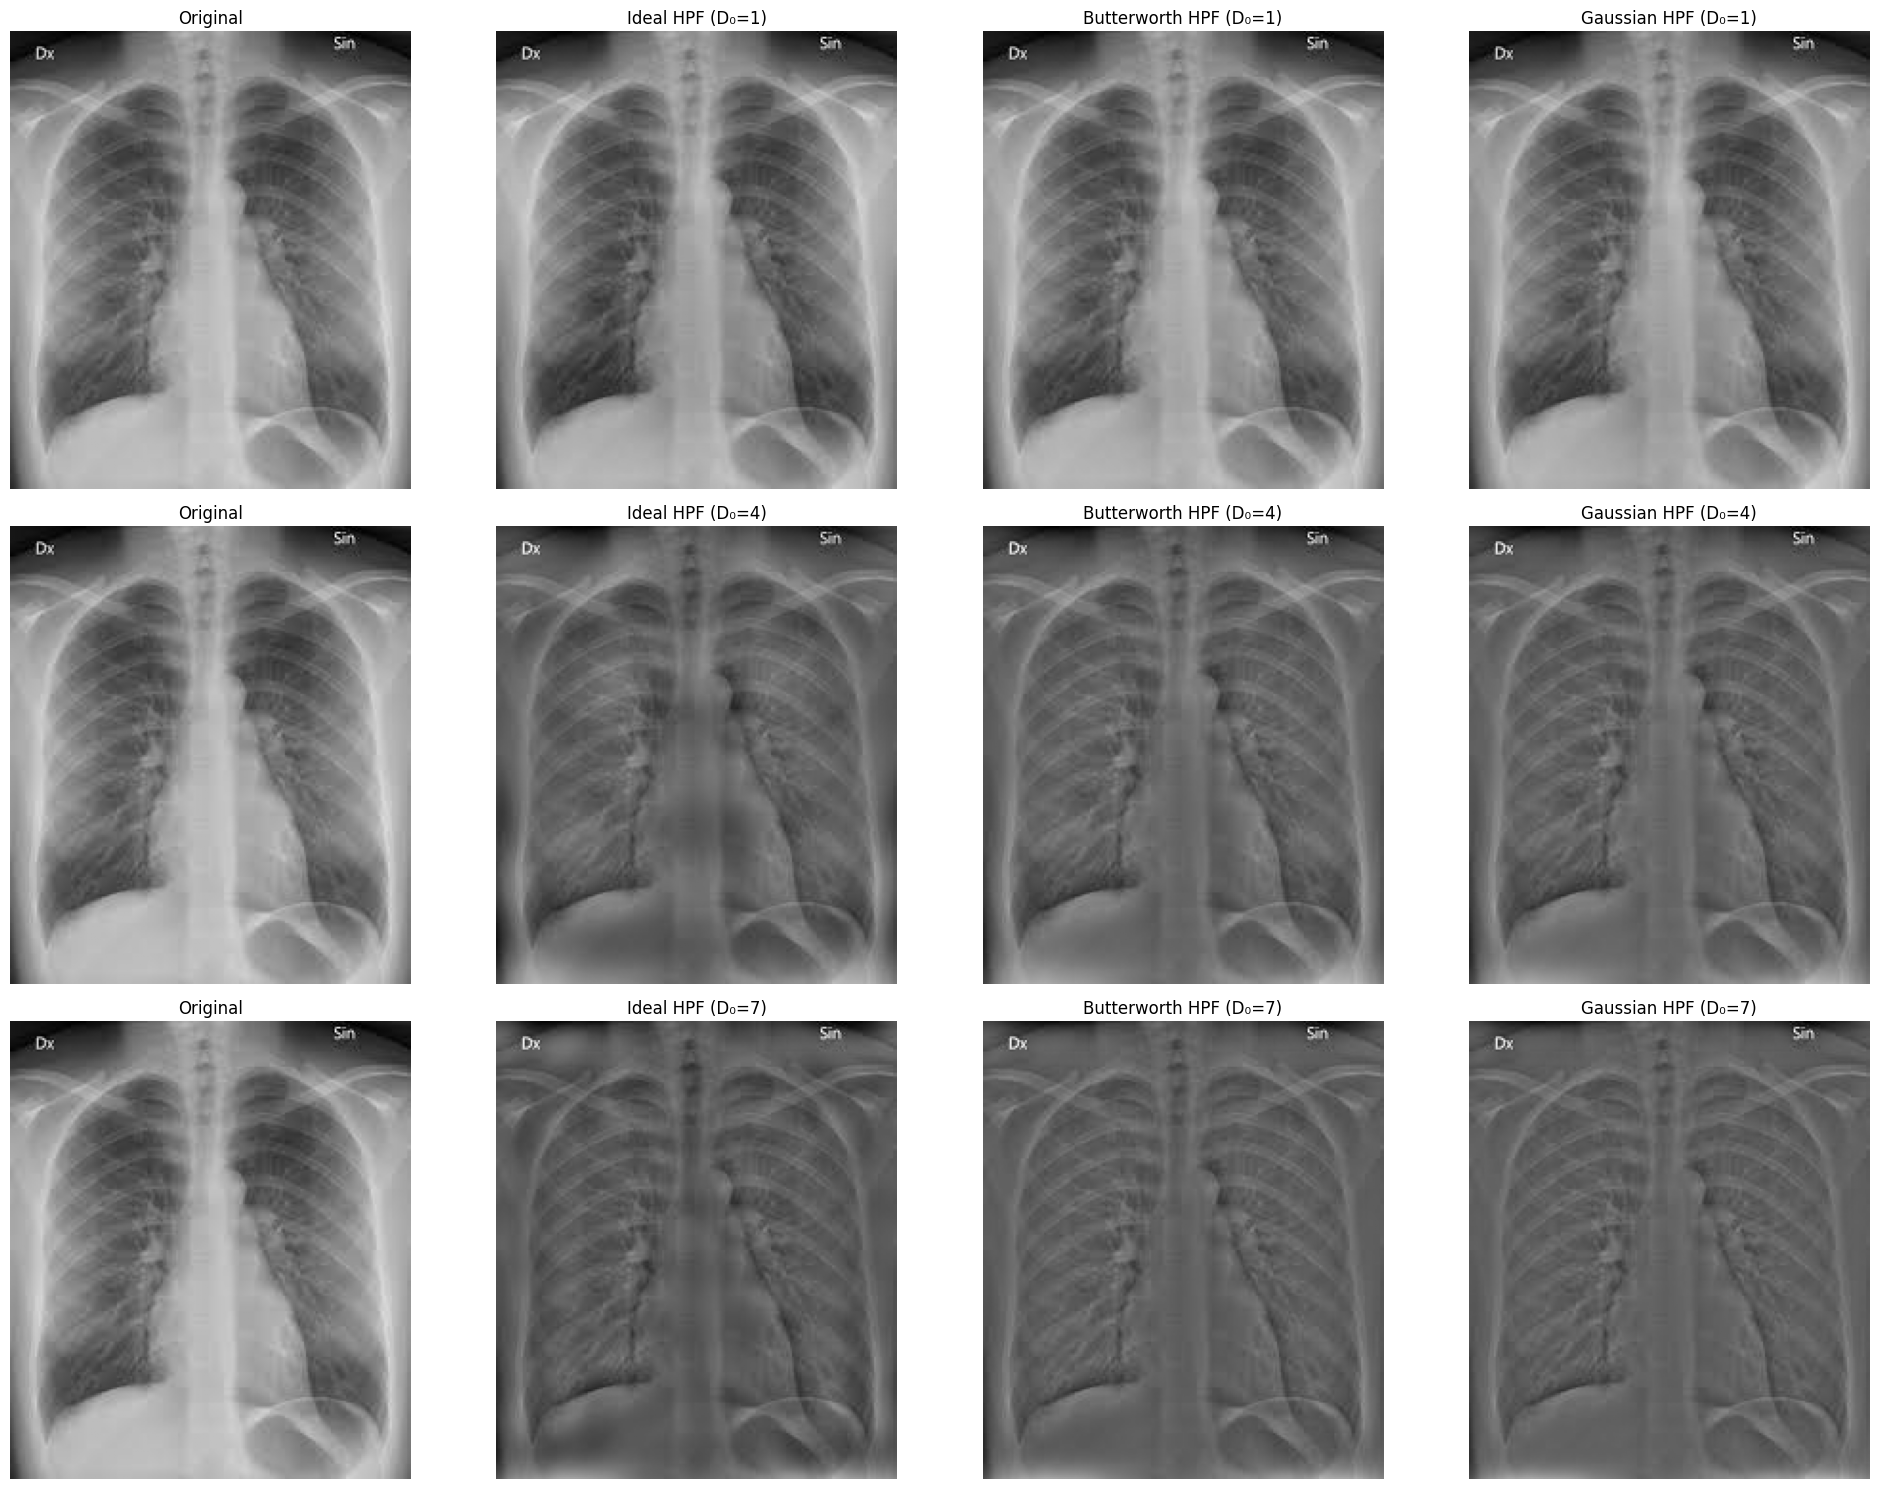

In [25]:
# https://en.wikipedia.org/wiki/Chest_radiograph
img = cv2.imread('data/xray-chest.jpeg')
gray_image = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Checking image size
print(f"Image shape: {gray_image.shape}")
rows, cols = gray_image.shape
max_distance = np.sqrt((rows/2)**2 + (cols/2)**2)
print(f"Maximum frequency distance: {max_distance:.2f}")

# For high-pass filters, use smaller cutoff values to preserve more detail
# Typical range: 1-5% of maximum frequency
cutoff_freq_low = int(0.01 * max_distance)     # 1% - subtle enhancement
cutoff_freq_medium = int(0.03 * max_distance)   # 3% - moderate enhancement
cutoff_freq_high = int(0.05 * max_distance)     # 5% - strong enhancement

print(f"Cutoff frequencies: {cutoff_freq_low}, {cutoff_freq_medium}, {cutoff_freq_high}")

cutoff_values = [cutoff_freq_low, cutoff_freq_medium, cutoff_freq_high]

fig, axes = plt.subplots(len(cutoff_values), 4, figsize=(20, 5*len(cutoff_values)))

for idx, cutoff in enumerate(cutoff_values):
    # Create filters
    ideal_f = create_ideal_hpf(gray_image.shape, cutoff)
    butter_f = create_butterworth_hpf(gray_image.shape, cutoff, order=2)
    gauss_f = create_gaussian_hpf(gray_image.shape, cutoff)
    
    # Apply filters
    img_ideal = apply_frequency_filter(gray_image, ideal_f)
    img_butter = apply_frequency_filter(gray_image, butter_f)
    img_gauss = apply_frequency_filter(gray_image, gauss_f)
    
    # Normalize for better visualization (high-pass results can have negative values)
    img_ideal = cv2.normalize(img_ideal, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    img_butter = cv2.normalize(img_butter, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    img_gauss = cv2.normalize(img_gauss, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    
    # Plot
    axes[idx, 0].imshow(gray_image, cmap='gray')
    axes[idx, 0].set_title('Original')
    axes[idx, 0].axis('off')

    axes[idx, 1].imshow(img_ideal, cmap='gray')
    axes[idx, 1].set_title(f'Ideal HPF (D₀={cutoff})')
    axes[idx, 1].axis('off')
    
    axes[idx, 2].imshow(img_butter, cmap='gray')
    axes[idx, 2].set_title(f'Butterworth HPF (D₀={cutoff})')
    axes[idx, 2].axis('off')
    
    axes[idx, 3].imshow(img_gauss, cmap='gray')
    axes[idx, 3].set_title(f'Gaussian HPF (D₀={cutoff})')
    axes[idx, 3].axis('off')

plt.tight_layout()
plt.show()

The experimental results demonstrate the progressive effects of high-pass filtering across three different cutoff frequencies (D₀=1, D₀=4, and D₀=7) applied to a posteroanterior chest radiograph. Given the image dimensions, these cutoff values represent extremely small percentages of the maximum frequency distance, allowing for precise control over edge enhancement while managing noise amplification.

**Effect of Cutoff Frequency on Edge Enhancement**

At D₀=1 (the lowest cutoff frequency tested), the high-pass filters produce minimal enhancement, resulting in images that closely resemble the original radiograph. This conservative filtering suppresses only the most dominant low-frequency components corresponding to large-scale intensity variations and background gradients. The subtle enhancement primarily affects the sharpest transitions in the image, such as the lung-diaphragm interface and the outer rib borders, while preserving the overall tonal distribution of the radiograph.

At D₀=4 (intermediate cutoff), the enhancement effect becomes substantially more pronounced. The costal margins (rib edges) exhibit significant sharpening, with individual ribs becoming more distinctly delineated against the pulmonary background. The cardiac silhouette border demonstrates enhanced definition, and the pulmonary vasculature becomes more visible throughout both lung fields. The vertebral column and mediastinal structures also show improved edge contrast. This level of enhancement represents a clinically useful balance, where anatomical boundaries are emphasized without excessive noise amplification or loss of contextual information.

At D₀=7 (the highest cutoff tested), the filtering produces aggressive edge enhancement with notable characteristics. The costal structures appear dramatically sharpened, with each rib presenting as a distinct high-contrast feature. The pulmonary vascular markings become prominently visible, revealing fine bronchovascular patterns that are subtle in the original image. However, this aggressive enhancement also begins to reveal the trade-off inherent in high-pass filtering: while anatomical edges are maximally emphasized, the uniform lung parenchyma regions appear darker and more uniform due to the suppression of low-frequency content, and subtle image noise becomes more apparent.

**Comparative Analysis of Filter Types**

The theoretical distinctions between the three high-pass filter types manifest differently than in low-pass filtering applications. At D₀=1, all three filters produce nearly identical results due to the minimal frequency attenuation applied. The differences become progressively more apparent as the cutoff frequency increases.

The ideal high-pass filter, characterized by its sharp discontinuous transition at D₀, demonstrates the most aggressive edge enhancement at higher cutoff values. At D₀=7, the IHPF produces the strongest edge emphasis on the costal margins and cardiac border. However, careful examination reveals subtle ringing artifacts, particularly visible as faint halos along high-contrast transitions such as the mediastinal borders and the superior aspects of the diaphragm. These artifacts, though less visually prominent than in low-pass applications, represent the spatial manifestation of the filter's rectangular frequency response (Gonzalez & Woods, 2018).

The Butterworth high-pass filter with second-order configuration provides a more gradual transition between suppressed and preserved frequencies. The resulting images exhibit smooth edge enhancement without the oscillatory artifacts characteristic of the ideal filter. At D₀=4 and D₀=7, the Butterworth filter produces clinically optimal results: anatomical structures demonstrate clear boundary definition, pulmonary vasculature is enhanced for improved visibility, and the overall image maintains diagnostic quality without introducing false features. The transfer function H(u,v) = 1/[1 + (D₀/D)^(2n)] ensures that edge enhancement occurs progressively rather than abruptly, preserving the natural appearance of anatomical transitions.

The Gaussian high-pass filter generates the smoothest enhancement among the three approaches. Its unique property of maintaining Gaussian characteristics in both frequency and spatial domains ensures complete absence of ringing artifacts. At D₀=7, the Gaussian filter produces edge enhancement that appears most natural to the human visual system, with anatomical boundaries emphasized through gradual intensity transitions rather than sharp discontinuities. The rib structures maintain realistic appearance while demonstrating improved definition, and the pulmonary vasculature is enhanced without introducing spurious high-frequency components that could be misinterpreted as pathological features.

**Clinical and Diagnostic Implications**

The selection of appropriate cutoff frequency for medical image enhancement requires careful consideration of diagnostic objectives and image characteristics. Low cutoff values (D₀ < 5 pixels for typical radiograph dimensions) provide conservative enhancement suitable for initial image review, where maintaining overall tonal relationships is paramount. Intermediate values (D₀ ≈ 5-10 pixels) offer clinically useful enhancement for identifying subtle fractures, small pulmonary nodules, and vascular abnormalities. Higher cutoff values (D₀ > 10 pixels) produce aggressive enhancement appropriate for specialized applications such as pneumothorax detection or fine bone structure analysis, though at the risk of amplifying image noise and reducing overall image quality.

For the chest radiograph examined here, the intermediate cutoff frequency (D₀=4) combined with either a Butterworth or Gaussian high-pass filter provides optimal diagnostic value. These configurations successfully enhance clinically relevant anatomical boundaries (including rib fracture sites, pulmonary nodule margins, and cardiac border abnormalities) while maintaining the natural appearance and tonal context necessary for accurate radiological interpretation. The minimal differences observed between filter types at lower cutoff values confirm that artifact concerns diminish when frequency attenuation is modest, while the clear superiority of Butterworth and Gaussian filters at higher cutoff values validates the importance of smooth frequency transitions in medical imaging applications where false features could lead to diagnostic errors.